In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Loading the dataset
df = pd.read_csv('onlinefoods.csv')
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [2]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12'],
      dtype='object')

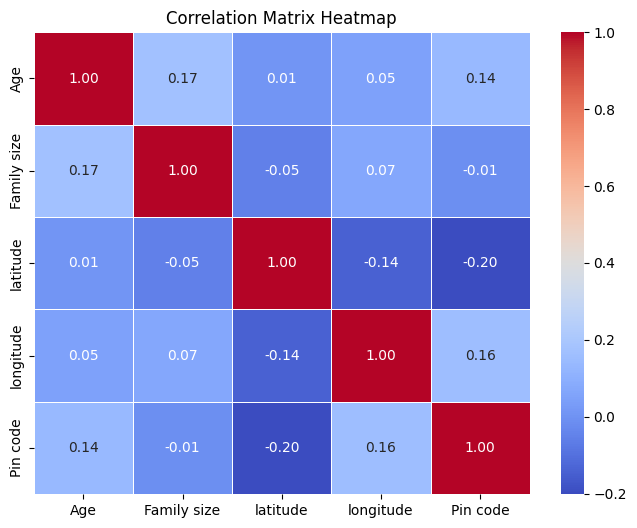

In [3]:
## General heatmap
import seaborn as sns
# Selecting only numerical columns for the correlation matrix
numerical_data = df[['Age', 'Family size', 'latitude', 'longitude', 'Pin code']]

# Compute the correlation matrix
correlation_matrix = numerical_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

/var/folders/dp/f1w59vsn4vqbvdmprd4rcvjw0000gn/T/ipykernel_13303/1432462735.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  column_data['Age'] = column_data['Age'].fillna(column_data['Age'].mean())


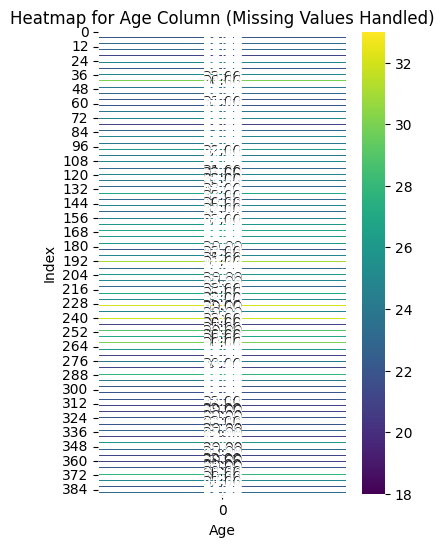

In [4]:
# handling missing values in heatmap

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('onlinefoods.csv')

# Select the column 
column_data = data[['Age']]

# Fill missing values in the selected column with the column mean
column_data['Age'] = column_data['Age'].fillna(column_data['Age'].mean())

# Convert the column to a 2D numpy array 
column_array = column_data.values

# Generate the heatmap for the single column
plt.figure(figsize=(4, 6))  # Adjust size for a single column
sns.heatmap(column_array, cmap='viridis', annot=True, fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Heatmap for Age Column (Missing Values Handled)')
plt.xlabel('Age')
plt.ylabel('Index')
plt.show()


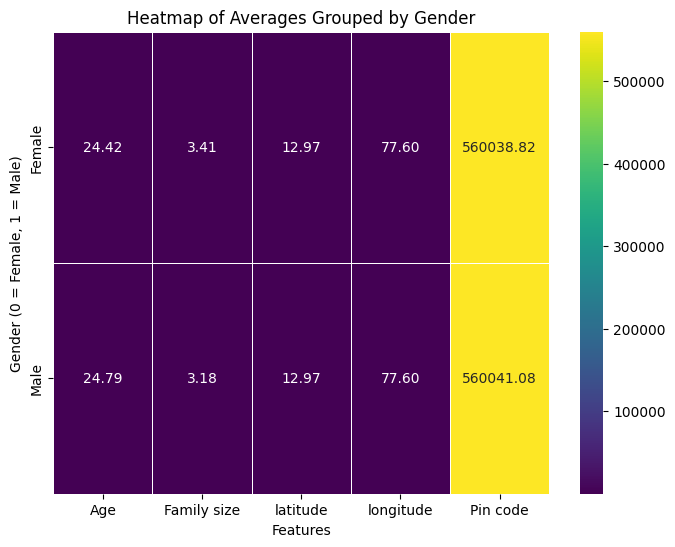

In [5]:
## Heatmap of Numeric Feature Means Grouped by categorical columns(gender)
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Group by Gender and calculate mean for numeric columns
grouped_data = numeric_data.groupby(data['Gender']).mean()

# Plot the heatmap for grouped data
plt.figure(figsize=(8, 6))
sns.heatmap(grouped_data, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Averages Grouped by Gender')
plt.xlabel('Features')
plt.ylabel('Gender (0 = Female, 1 = Male)')
plt.show()


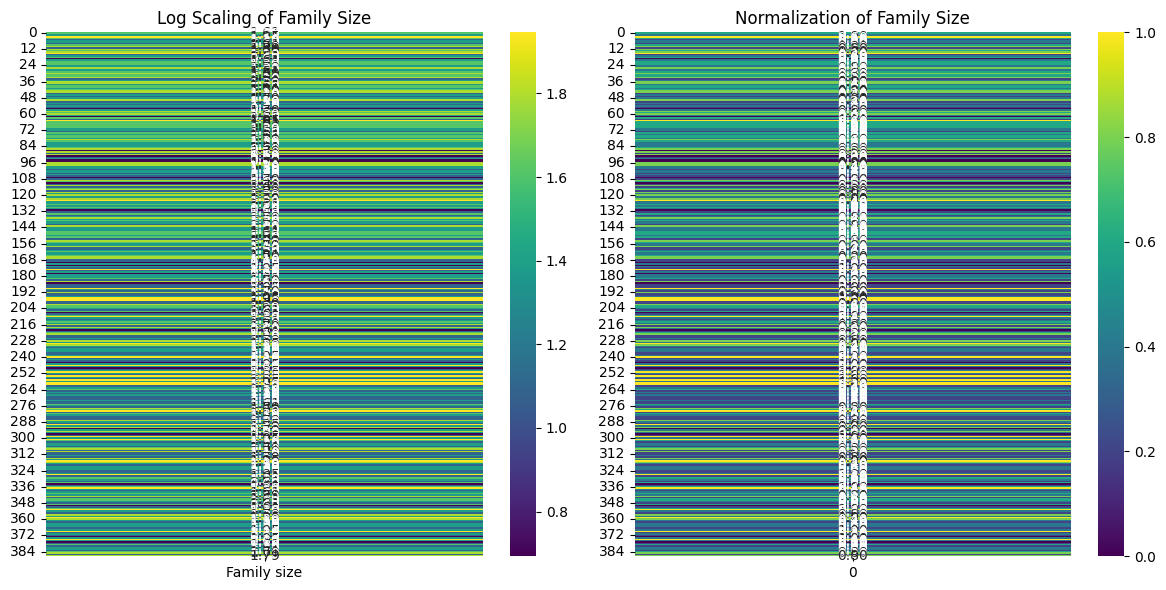

In [6]:
# 1. Log Scaling:
# Log scaling is often used to handle data with large ranges, compressing the scale and making patterns more visible.

# 2. Normalization:
# Normalization scales the data to a specific range, typically between 0 and 1, so that all features have a similar scale. This is particularly useful when comparing features with different ranges.

import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Extract the Family size column
family_size_data = df[['Family size']]

# 1. Log Scaling (apply log transformation to Family size)
# Add a small constant to avoid log(0) and make all values positive
family_size_log_scaled = np.log(family_size_data + 1)

# 2. Normalization (scale Family size to range [0, 1])
scaler = MinMaxScaler()
family_size_normalized = scaler.fit_transform(family_size_data)

# Plot the log-scaled data
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(family_size_log_scaled, cmap='viridis', annot=True, fmt='.2f', cbar=True)
plt.title('Log Scaling of Family Size')

# Plot the normalized data
plt.subplot(1, 2, 2)
sns.heatmap(family_size_normalized, cmap='viridis', annot=True, fmt='.2f', cbar=True)
plt.title('Normalization of Family Size')

plt.tight_layout()
plt.show()
